# Applied ML Final Project: Predicting Lending Approval Outcomes 💳
### Authors: Sam & Nishi

## Dataset Metadata

In [93]:
import json # Needed to look at metadata

with open('loan-approval-classification-data-metadata.json') as f:
    meta = json.load(f)

In [94]:
print("Dataset Name:", meta["name"])
print("Description:", meta["description"])
print("Author:", meta["creator"]["name"])
print("Files Included:")

for item in meta["distribution"]:
    print(f"- {item['name']} ({item['encodingFormat']})")

Dataset Name: Loan Approval Classification Dataset
Description: ## 1. **Data Source**
This dataset is a synthetic version inspired by the original [Credit Risk dataset on Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) and enriched with additional variables based on [Financial Risk for Loan Approval data](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval). SMOTENC was used to simulate new data points to enlarge the instances. The dataset is structured for both categorical and continuous features.

## 2. **Metadata**
The dataset contains 45,000 records and 14 variables, each described below:

| Column                         | Description                                          | Type        |  
|--------------------------------|------------------------------------------------------|-------------|  
| `person_age`                   | Age of the person                                    | Float       |  
| `person_gender`            

## Imports

In [95]:
# Basic mathematical imports and visualization packages
import pandas as pd # Dataframe manipulation, math
import numpy as np # Math calculations
import matplotlib.pyplot as plt # Used in seaborn
import seaborn as sns # Visualizations

# Train/test split
from sklearn.model_selection import train_test_split  # To split training and testing data

# Preprocessing + pipeline tools
from imblearn.over_sampling import SMOTE # Oversampling algorithm
from imblearn.pipeline import Pipeline # Full ML pipeline w/ imbalanced dataset tools
from sklearn.feature_selection import SelectKBest, f_classif # Selects best features for a model
from sklearn.model_selection import GridSearchCV, StratifiedKFold # Used for tuning hyperparameters via a search
from sklearn.preprocessing import RobustScaler, OneHotEncoder  # Scaling/normalizing, encoding categorical variables
from sklearn.compose import ColumnTransformer # Different transforms per column type                            

# Metrics: Emphasis on class imbalance
from sklearn.metrics import ( 
    classification_report, # Comprehensive classification metrics report
    ConfusionMatrixDisplay, # Used for confusion matrix visualization
    roc_auc_score, # Used to calculate roc-auc score
    RocCurveDisplay, # Used to display roc-auc elbow curve
    accuracy_score, # Used to calculate basic accuracy score
    f1_score # Used to calculate f1 score
)

# Models :)
from sklearn.linear_model import LogisticRegression          # Logistic regression ml model
from sklearn.ensemble import RandomForestClassifier          # Random forest ml model
from xgboost import XGBClassifier                            # Gradient-boosted decision tree ml model

## Exploratory Data Analysis

In [96]:
# Path
path = "https://raw.githubusercontent.com/samstrc/AppliedML_FinalProj/98d4784b6eb1d42a68e0283f86777bdb03bb2afc/loan_data.csv"
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [97]:
# Check for missing data
missing_sum = df.isna().sum().sum()
if (missing_sum != 0):
    print(f"There are {missing_sum} missing values in the dataset!")
else:
    print("There are no missing values in this dataset.")

There are no missing values in this dataset.


### Target/Response Variable Checks

In [98]:
# Check for a class imbalance
class_imbalance = df["loan_status"].value_counts(normalize=True)
class_imbalance

loan_status
0   0.78
1   0.22
Name: proportion, dtype: float64

It is shown that the class imbalance is rather significant, meaning the number of applications that were approved make up 22% of all observations in the data. SMOTE must be considered or other oversampling methods. Reliance on accuracy alone is not suiteable for this dataset. F1, precision/recall, ROC/AUC, and confusion matrix statistics should be analyzed closely.

### Numeric Predictor Checks

In [99]:
pd.set_option('display.float_format', lambda x: f"{x:,.2f}") # Change numeric variable expression 

df_numeric = df.select_dtypes(include="number")
df_numeric

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.00,"71,948.00",0,"35,000.00",16.02,0.49,3.00,561,1
1,21.00,"12,282.00",0,"1,000.00",11.14,0.08,2.00,504,0
2,25.00,"12,438.00",3,"5,500.00",12.87,0.44,3.00,635,1
3,23.00,"79,753.00",0,"35,000.00",15.23,0.44,2.00,675,1
4,24.00,"66,135.00",1,"35,000.00",14.27,0.53,4.00,586,1
...,...,...,...,...,...,...,...,...,...
44995,27.00,"47,971.00",6,"15,000.00",15.66,0.31,3.00,645,1
44996,37.00,"65,800.00",17,"9,000.00",14.07,0.14,11.00,621,1
44997,33.00,"56,942.00",7,"2,771.00",10.02,0.05,10.00,668,1
44998,29.00,"33,164.00",4,"12,000.00",13.23,0.36,6.00,604,1


In [100]:
df_numeric.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,"45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00"
mean,27.76,"80,319.05",5.41,"9,583.16",11.01,0.14,5.87,632.61,0.22
std,6.05,"80,422.50",6.06,"6,314.89",2.98,0.09,3.88,50.44,0.42
min,20.00,"8,000.00",0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,"47,204.00",1.00,"5,000.00",8.59,0.07,3.00,601.00,0.00
50%,26.00,"67,048.00",4.00,"8,000.00",11.01,0.12,4.00,640.00,0.00
75%,30.00,"95,789.25",8.00,"12,237.25",12.99,0.19,8.00,670.00,0.00
max,144.00,"7,200,766.00",125.00,"35,000.00",20.00,0.66,30.00,850.00,1.00


A few things to note here: 
- The middle 50% of people applying for a loan were between the ages of 24 and 30
- The middle 50% of loan interest rates were between 8.59-12.99%, with the average being 11%. 

Response Variable:
- The mean is 22, also showing the class imbalance from a different angle.

Skew: 
- Income is extremely right skewed
- Loan ammount is extremly right skewed
- **Both should be visualized for further inspection**

Outliers:
- A few very rich people applied for a loan.
- Someone was recorded to of had 125 years of work expierience?
- Someone was recorded to of had 30 years of credit history. It may be worth checking their age to make sure this is accurate. 

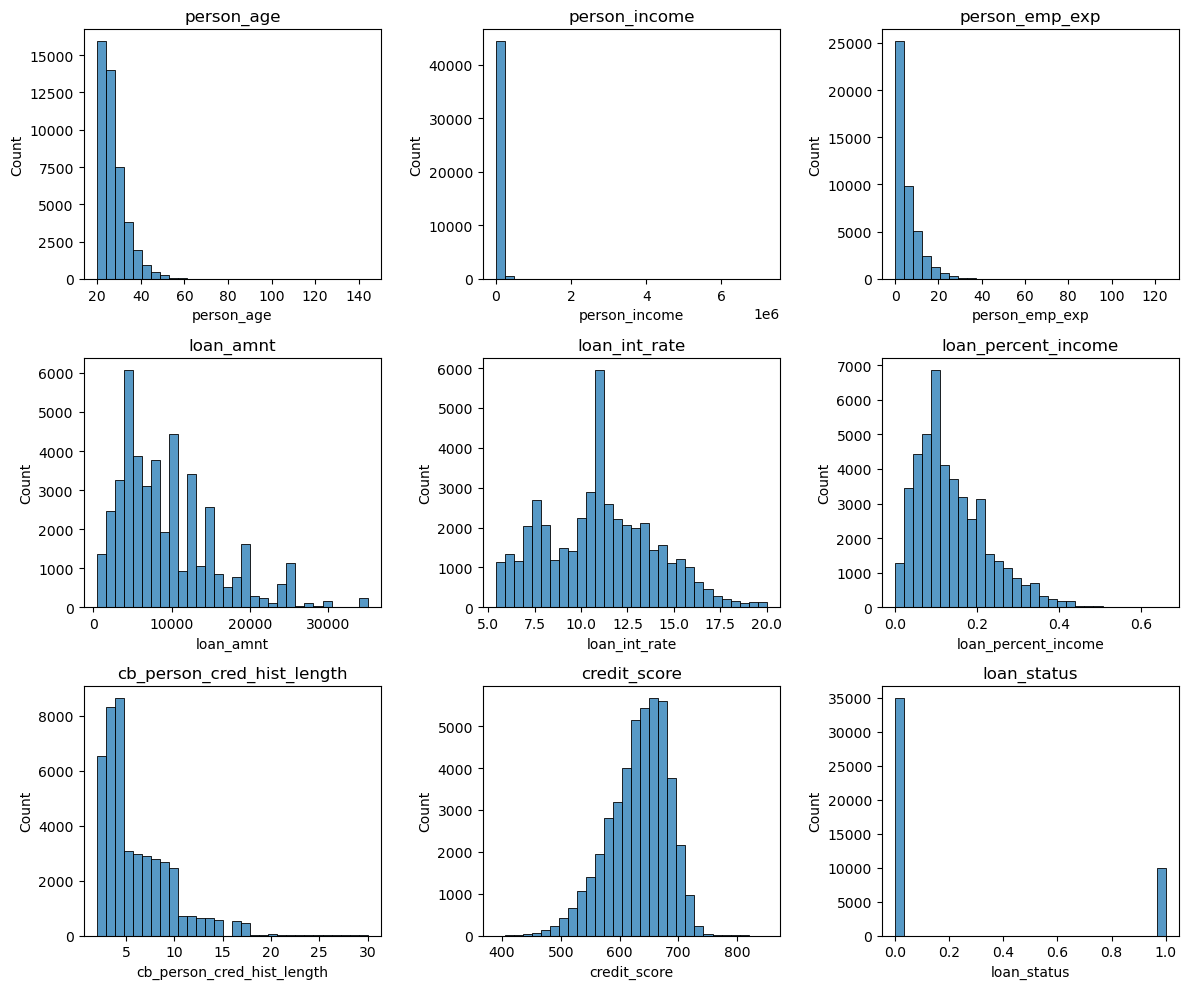

In [101]:
# Visualize all numeric predictors
# Histograms 
num_cols = df_numeric.columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.histplot(df_numeric[col], bins=30, kde=False)
    plt.title(col)

plt.tight_layout()
plt.show()

The numeric predictors show substantial right skew across most variables in the dataset. Person income, employment experience, loan percent income, and age all display heavy right tails and a concentration of values near the lower end, with several extreme outliers, such as incomes in the millions, ages above 100, and employment experience exceeding 100 years. These outliers suggest either data-entry issues or synthetic artifacts and may require clipping or transformation before modeling.

Loan interest rate and credit score are among the cleanest distributions, with credit score showing a nearly bell-shaped distribution and loan interest rates centered around 8–13%. Loan amount is moderately skewed but shows a wide spread across applicants.

The target variable **loan_status** is evidently heavily imbalanced here as well, with approximately **78%** denials and **22%** approvals.

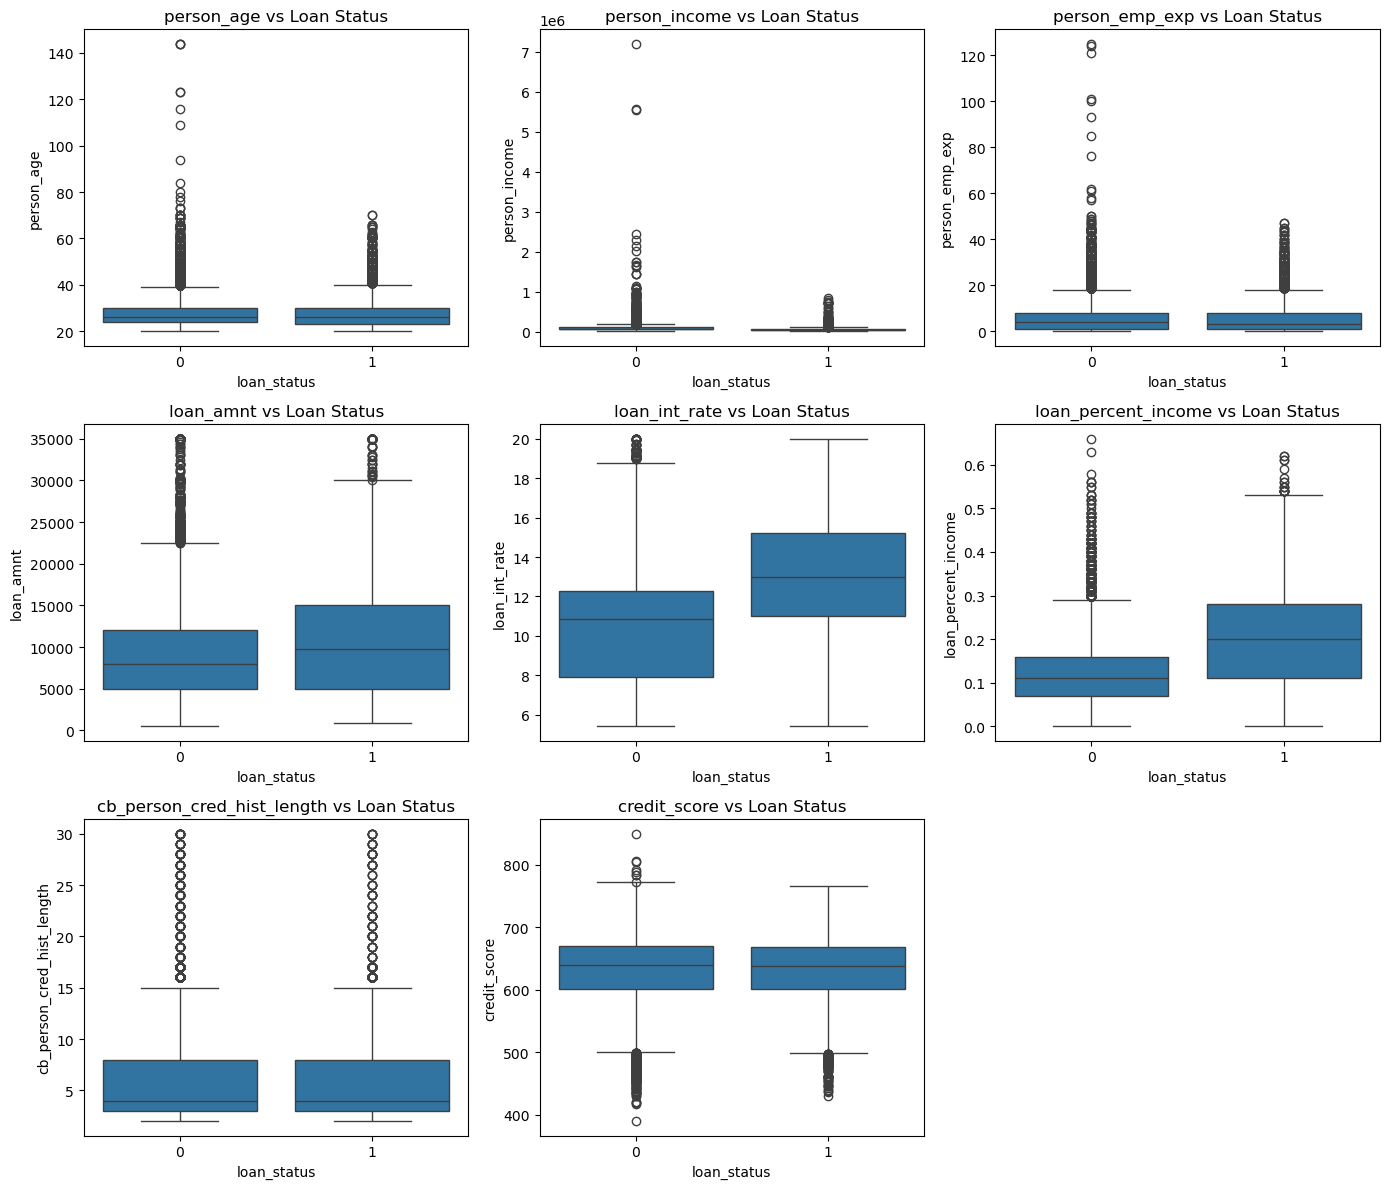

In [102]:
# Boxplots to visualize against target variable
# Select numeric predictors but exclude the target column
num_cols = df_numeric.columns.drop("loan_status")

plt.figure(figsize=(14, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(data=df, x="loan_status", y=col)
    plt.title(f"{col} vs Loan Status")
    plt.tight_layout()

plt.show()

Box plots that show larger separations between the two loan_status groups indicate that the numeric predictor differs meaningfully between approved and denied applicants. This suggests the variable may be a strong predictor of the target.

The variables showing the clearest separation are:
-	loan_int_rate
-	loan_percent_income
-	loan_amnt (moderate separation)

Demographic variables like age and employment experience show little class separation and are likely weak contributors.

Correlations of each predictor and the response variable:
 person_income                -0.14
person_age                   -0.02
person_emp_exp               -0.02
cb_person_cred_hist_length   -0.01
credit_score                 -0.01
loan_amnt                     0.11
loan_int_rate                 0.33
loan_percent_income           0.38
loan_status                   1.00
Name: loan_status, dtype: float64


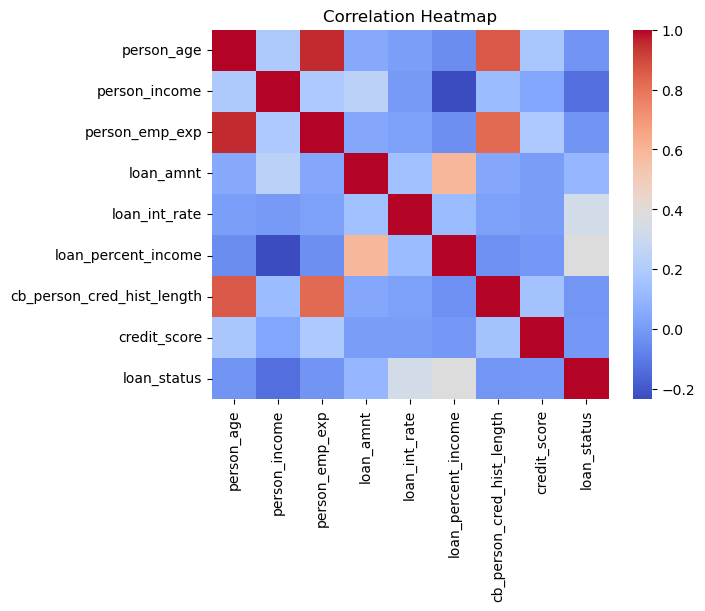

In [103]:
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
print("Correlations of each predictor and the response variable:\n", df_numeric.corr()["loan_status"].sort_values())

In [104]:
# Note high correlations for future investigation
corr_matrix = df_numeric.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Threshold
threshold = 0.6

# Find pairs above the threshold
high_corr = [(col1, col2, upper.loc[col1, col2])
             for col1 in upper.columns
             for col2 in upper.columns
             if upper.loc[col1, col2] > threshold]

high_corr

[('person_age', 'person_emp_exp', 0.9544121607878328),
 ('person_age', 'cb_person_cred_hist_length', 0.86198455770491),
 ('person_emp_exp', 'cb_person_cred_hist_length', 0.8242715421191774)]

Highly correlated variables might confuse linear models, or not add much to other models. It may be useful to remember these correlations when considering dropping columns. 

### Categorical Variable Checks

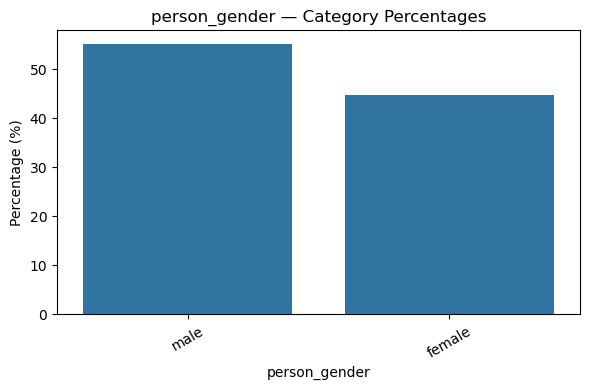

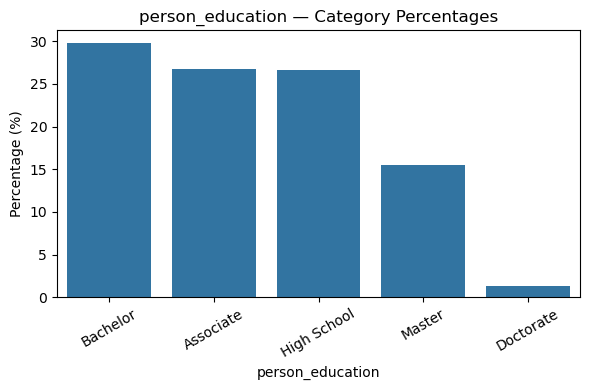

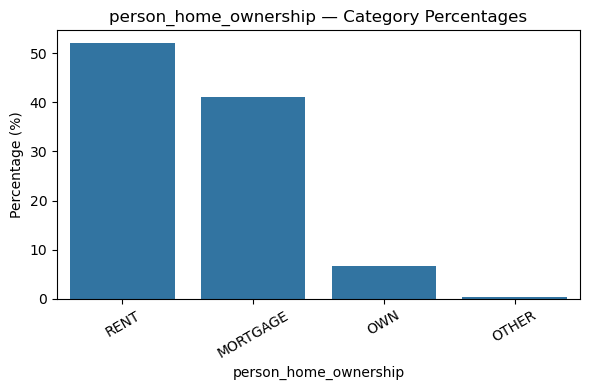

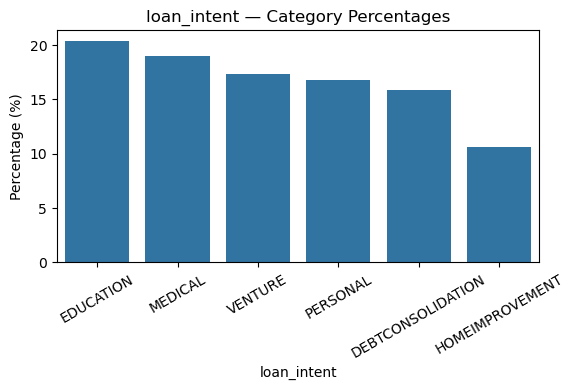

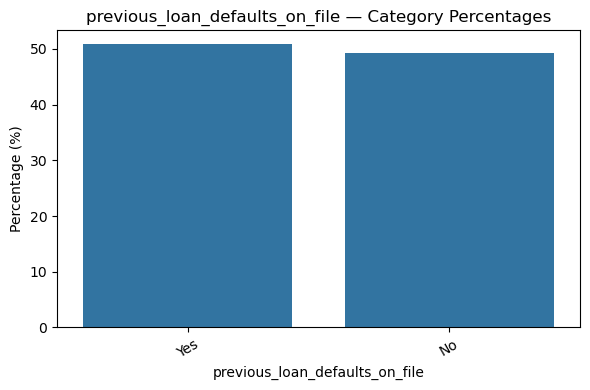

In [105]:
# Extract categorical columns 
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percent")
        .reset_index()
        .pipe(lambda d: sns.barplot(data=d, x=col, y="percent"))
    )
    plt.title(f"{col} — Category Percentages")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

The categorical predictors show healthy and well-distributed category frequencies across most variables, with slight imbalances in homeownership and rare categories like Doctorate education and Other ownership. Gender, education, and loan intent are fairly balanced, while previous loan defaults are almost evenly split, suggesting these features may meaningfully contribute to loan approval predictions.

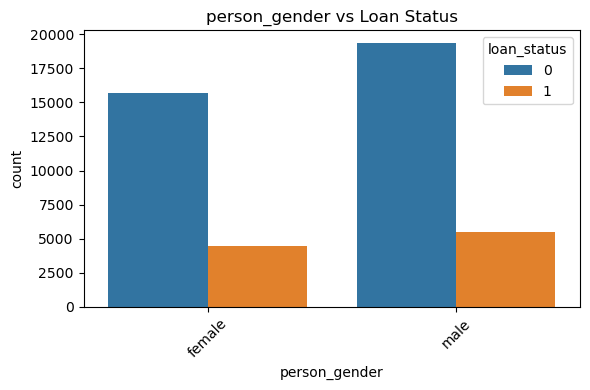

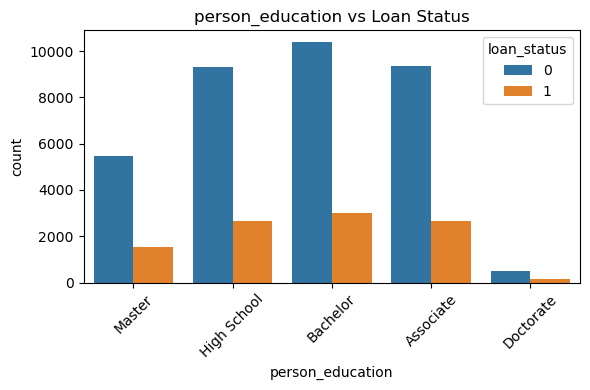

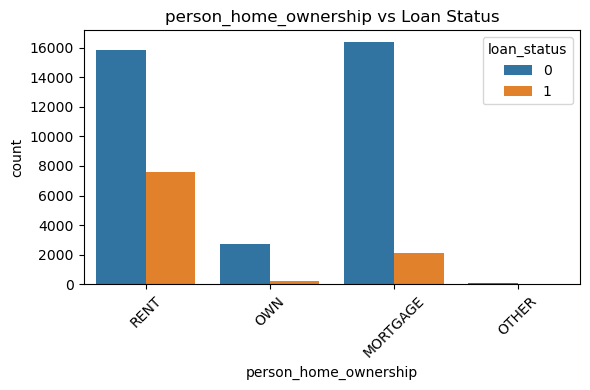

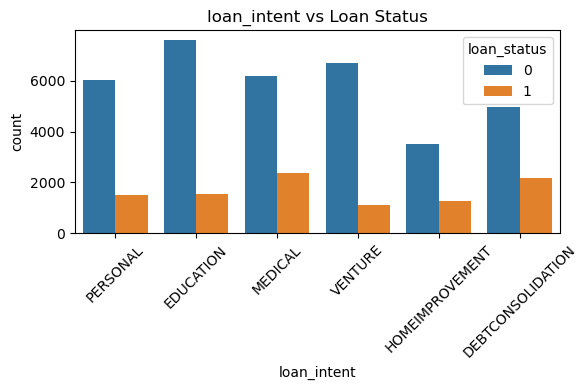

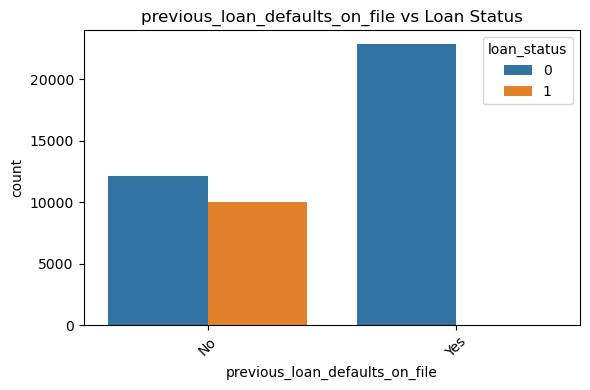

In [106]:
# Visualize each category against the target
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="loan_status")
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The categorical variables reveal several patterns in loan approval behavior. Gender shows virtually no meaningful difference, with male and female applicants experiencing nearly identical approval and denial rates. Education level also has only mild effects. Bachelor’s, Associate, and High School groups behave similarly, while Master’s applicants appear slightly more likely to be approved, though the difference is small and Doctorate observations are too rare to interpret. Home ownership stands out as a much stronger predictor. Renters and mortgage holders receive substantially more approvals compared to those who list “own” or “other,” suggesting lenders view the former groups as more stable or lower risk. Loan intent also demonstrates some variation, with education, medical, and venture-related loans seeing higher approval counts, while home improvement loans tend to receive fewer approvals overall. The clearest signal comes from previous defaults: applicants with no prior defaults receive many approvals, whereas those with defaults on file are almost always denied. Overall, home ownership, loan intent, and especially prior default history appear to carry the strongest predictive power among the categorical variables.

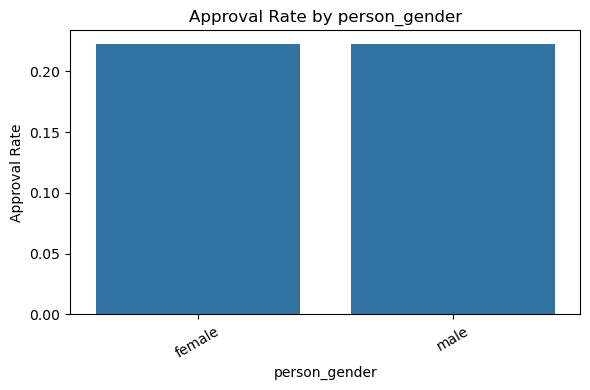

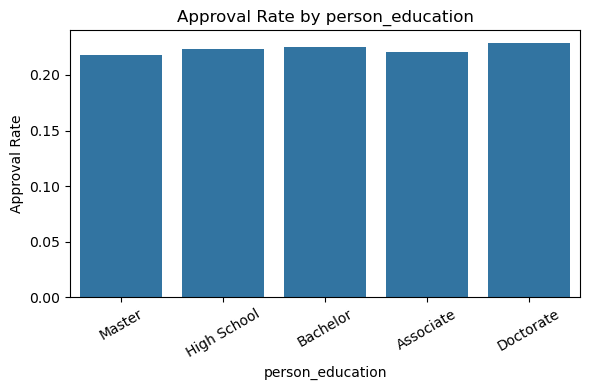

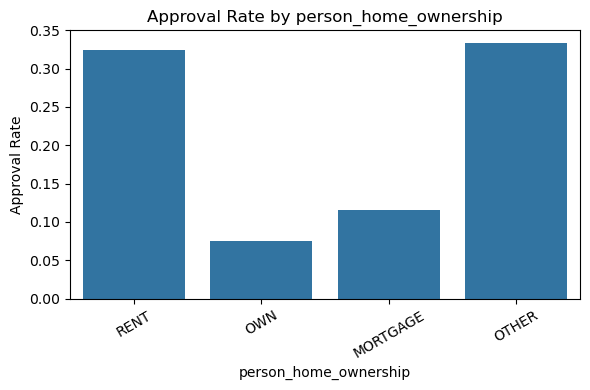

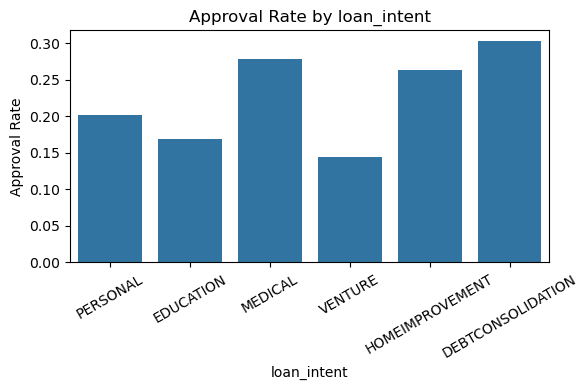

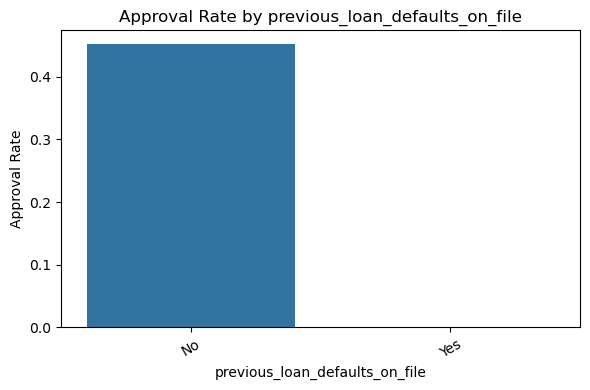

In [107]:
# Approval rate per category
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x=col,
        y="loan_status",   # mean approval rate per category
        estimator=np.mean,
        errorbar=None
    )
    plt.title(f"Approval Rate by {col}")
    plt.ylabel("Approval Rate")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

The approval rate visualizations give a clearer picture of how each categorical variable relates to loan approval likelihood.

Gender again shows no material effect. Males and females have nearly identical approval rates, both hovering slightly above 0.22. Education levels also produce very similar approval rates across categories, while Doctorate appears slightly higher, the category is too small to draw strong conclusions, and the remaining groups cluster tightly around the same range. This suggests that education level has minimal predictive influence in this dataset.

Home ownership, however, shows substantial variation. Renters and those classified as “OTHER” have significantly higher approval rates (around 0.32–0.34), while applicants who “OWN” their home outright have the lowest approval rate at roughly 0.07. Mortgage holders fall in the middle. This reinforces the earlier finding that home ownership status carries meaningful signal and may reflect stability, risk, or lender preferences embedded in the synthetic data.

Loan intent also shows noticeable differences in approval probability. Medical and debt consolidation loans receive the highest approval rates (around 0.28–0.30), while venture loans have the lowest rate at roughly 0.14. Personal, education, and home improvement loans fall in the mid-range. These patterns imply that the reason for the loan is tied moderately to approval likelihood.

Finally, previous loan defaults are by far the strongest categorical predictor. Applicants with no prior defaults show an approval rate near 0.45, whereas applicants with defaults on file have an approval rate close to zero. This extreme separation aligns with the earlier count-based analysis and indicates this variable will definitely influence model predictions.

# Modeling
## Logistic Regression

In [108]:
# Read data from csv and train-test split
X = df.drop("loan_status", axis=1)
y = df["loan_status"]
# One consistent split for ALL models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y # Helps w/ class imbalance
)

In [109]:
# Identify categorical cols and numerical cols
numerical_cols = X.select_dtypes (include = ['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("Categorical columns are: " , categorical_cols)
print("Numerical columns are: ", numerical_cols)

Categorical columns are:  Index(['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file'], dtype='object')
Numerical columns are:  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'], dtype='object')


In [110]:
# Transform the categorical variables
ct = ColumnTransformer(
    transformers = [("encoder", OneHotEncoder(drop='first'), categorical_cols)], remainder = 'passthrough')

X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)
X_train_encoded

feature_names = ct.get_feature_names_out()  # used in conclusions section

In [111]:
# Scaling the features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)
X_train_scaled

array([[-1.        ,  0.        ,  0.        , ..., -0.41666667, -0.4       , -0.33333333],
       [ 0.        ,  1.        ,  0.        , ...,  0.08333333,  0.4       , -0.62318841],
       [-1.        ,  0.        ,  0.        , ...,  3.08333333,  0.6       , -1.36231884],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.25      ,  0.        , -0.28985507],
       [ 0.        ,  0.        ,  0.        , ...,  0.08333333,  0.2       ,  0.73913043],
       [ 0.        ,  0.        ,  0.        , ..., -0.08333333,  0.6       ,  0.50724638]])

In [112]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ("under", SMOTE()), # SMOTE oversampling to handle class imbalance
    ("kbest", SelectKBest(f_classif)), # Find best predictors
    ("logreg", LogisticRegression(max_iter=500)) # Model type
])

# Logistic Regression Param Grid
lr_param_grid = {
    "kbest__k": [5, 7, 10],
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__class_weight": [None, "balanced"]
}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grid Search for Logistic Regression
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Fit on Training Data
lr_grid.fit(X_train_scaled, y_train)

# Extract Best Model
best_lr = lr_grid.best_estimator_

print("LR Best Params:", lr_grid.best_params_)
print("LR Best CV F1:", lr_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
LR Best Params: {'kbest__k': 10, 'logreg__C': 10, 'logreg__class_weight': None}
LR Best CV F1: 0.7381241963471126


Training Accuracy: 0.8565
Test Accuracy: 0.8538888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.62      0.91      0.74      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.88      0.82      9000
weighted avg       0.89      0.85      0.86      9000

ROC-AUC Score: 0.9502983571428572


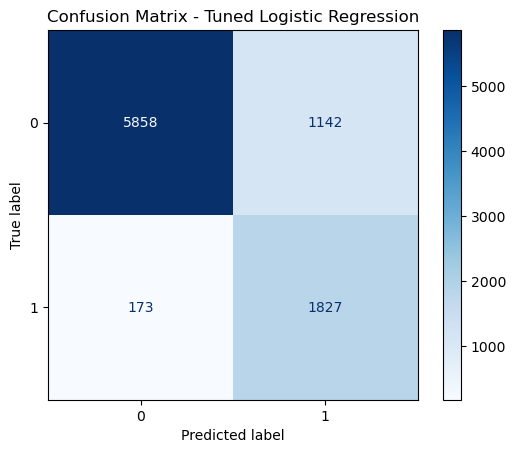

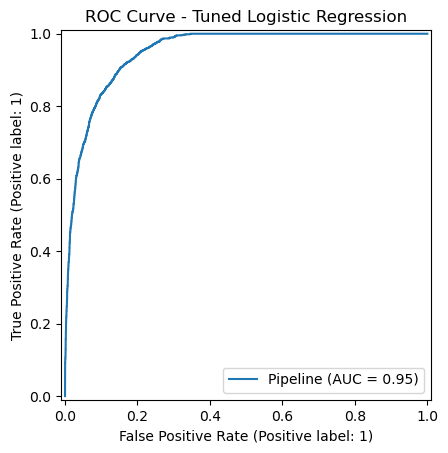

In [113]:
# Accuracy
train_score = best_lr.score(X_train_scaled, y_train)
test_score  = best_lr.score(X_test_scaled, y_test)

# Predictions
y_pred = best_lr.predict(X_test_scaled)

print("Training Accuracy:", train_score)
print("Test Accuracy:", test_score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC
y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test
)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

## Random Forest

In [114]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=0)), # Oversampling
    ("kbest", SelectKBest(f_classif)),  # let k be tuned
    ("rf", RandomForestClassifier(random_state=0, n_jobs=-1)) # Classifier
])

In [ ]:
rf_param_grid = {
    "kbest__k": [7, 10],              # 2
    "rf__n_estimators": [200],        # 1
    "rf__max_depth": [10, None],      # 2
    "rf__min_samples_split": [2, 5],  # 2
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)  # 3-fold instead of 5

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train_encoded, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_ 

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Training Accuracy: 0.99125
Test Accuracy: 0.9218888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.83      0.82      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.92      0.92      0.92      9000

ROC-AUC Score: 0.9737285


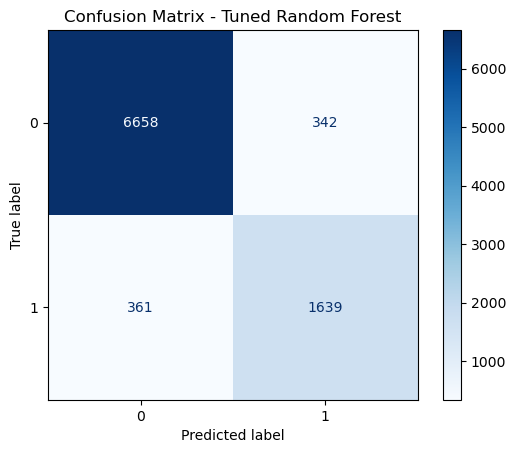

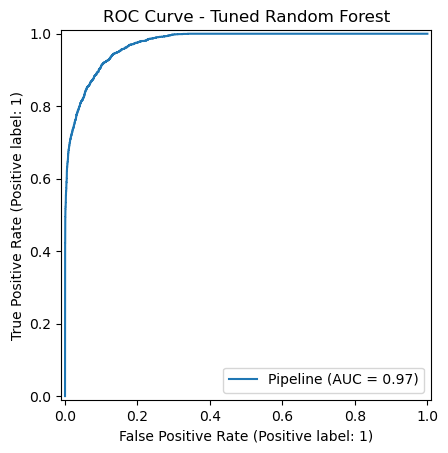

In [ ]:
# Use the tuned RF model instead of the og pipeline
model = best_rf

# Accuracy
train_score = model.score(X_train_encoded, y_train)
test_score  = model.score(X_test_encoded, y_test)

# Predictions
y_pred = model.predict(X_test_encoded)

print("Training Accuracy:", train_score)
print("Test Accuracy:", test_score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
y_proba = model.predict_proba(X_test_encoded)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_encoded,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# ROC Curve Plot
RocCurveDisplay.from_estimator(
    model,
    X_test_encoded,
    y_test
)
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

## XGBoost (Gradient-boosted Tree)

In [ ]:
# XGBoost pipeline
xgb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=0)), # Oversampling again to help with class imbalance
    ("kbest", SelectKBest(f_classif)),  # we'll tune k
    ("xgb", XGBClassifier( 
        objective="binary:logistic", # Specify resp var type
        eval_metric="logloss", # Specify loss
        random_state=0, # Seed
        n_jobs=-1 # Number of jobs
    ))
])

In [ ]:
xgb_param_grid = {
    "kbest__k": [7, 10],             # 2 options
    "xgb__n_estimators": [200],      # 1 option
    "xgb__max_depth": [3, 5],        # 2 options
    "xgb__learning_rate": [0.05, 0.1]# 2 options
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",        # still optimizing F1 for class 1
    cv=cv, # Cross validation
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train_encoded, y_train)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV F1:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGB params: {'kbest__k': 10, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}
Best XGB CV F1: 0.8253259724132417


XGB Training Accuracy: 0.9321388888888889
XGB Test Accuracy: 0.9255555555555556

XGB Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7000
           1       0.82      0.85      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.89      0.90      0.89      9000
weighted avg       0.93      0.93      0.93      9000

XGB Test ROC-AUC: 0.9745197499999999


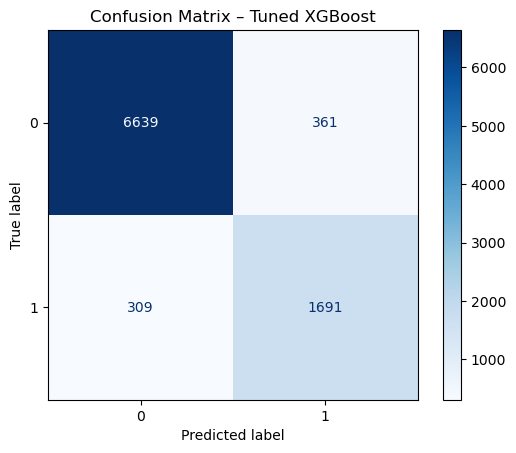

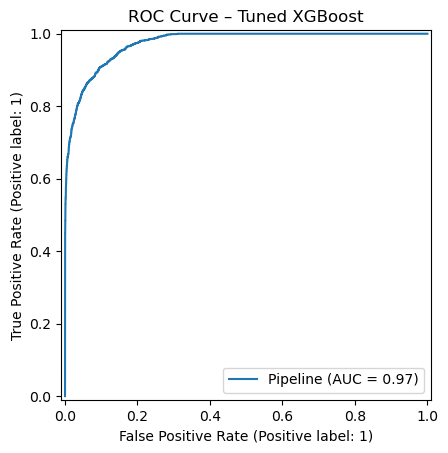

In [ ]:
model = best_xgb

# Accuracy
train_acc_xgb = model.score(X_train_encoded, y_train)
test_acc_xgb  = model.score(X_test_encoded, y_test)

print("XGB Training Accuracy:", train_acc_xgb)
print("XGB Test Accuracy:", test_acc_xgb)

# Predictions
y_pred_xgb = model.predict(X_test_encoded)

print("\nXGB Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# ROC-AUC
y_proba_xgb = model.predict_proba(X_test_encoded)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("XGB Test ROC-AUC:", roc_auc_xgb)

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_encoded,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

RocCurveDisplay.from_estimator(
    model,
    X_test_encoded,
    y_test
)
plt.title("ROC Curve – Tuned XGBoost")
plt.show()

# Conclusions
### Model Summaries

In [ ]:
# Logistic Regression
y_proba_log = best_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_log  = best_lr.predict(X_test_scaled)

rows = []

rows.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_log),
    "f1_class1": f1_score(y_test, y_pred_log),
    "roc_auc": roc_auc_score(y_test, y_proba_log),
})

# Random Forest
y_proba_rf = best_rf.predict_proba(X_test_encoded)[:, 1]
y_pred_rf  = best_rf.predict(X_test_encoded)

rows.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1_class1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
})

# XGBoost ** The winner! **
y_proba_xgb = best_xgb.predict_proba(X_test_encoded)[:, 1]
y_pred_xgb  = best_xgb.predict(X_test_encoded)

rows.append({
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "f1_class1": f1_score(y_test, y_pred_xgb),
    "roc_auc": roc_auc_score(y_test, y_proba_xgb),
})

results_df = pd.DataFrame(rows)
print(results_df)


print("LogReg best params:", lr_grid.best_params_)
print("RF best params:", rf_grid.best_params_)
print("XGB best params:", xgb_grid.best_params_)


                 model  accuracy  f1_class1  roc_auc
0  Logistic Regression      0.85       0.73     0.95
1        Random Forest      0.92       0.82     0.97
2              XGBoost      0.93       0.83     0.97
LogReg best params: {'kbest__k': 10, 'logreg__C': 0.1, 'logreg__class_weight': None}
RF best params: {'kbest__k': 10, 'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
XGB best params: {'kbest__k': 10, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}


### FINAL MODEL: XGBoost Spotlight

                                       feature  importance
5  encoder__previous_loan_defaults_on_file_Yes        0.79
1          encoder__person_home_ownership_RENT        0.07
4                 encoder__loan_intent_VENTURE        0.03
2               encoder__loan_intent_EDUCATION        0.03
3                 encoder__loan_intent_MEDICAL        0.02
9               remainder__loan_percent_income        0.02
8                     remainder__loan_int_rate        0.02
0           encoder__person_home_ownership_OWN        0.01
6                     remainder__person_income        0.01
7                         remainder__loan_amnt        0.00


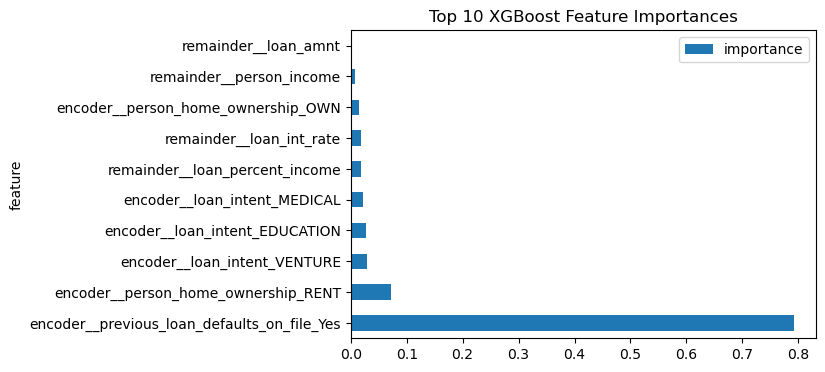

Best XGBoost Parameters:
 {'kbest__k': 10, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 200}


In [ ]:
# Get the SelectKBest mask from XGBoost pipeline
kbest_xgb = best_xgb.named_steps["kbest"]
xgb_model = best_xgb.named_steps["xgb"]

# Indices of selected features
selected_indices_xgb = kbest_xgb.get_support(indices=True)

# Map indices to actual feature names
selected_feature_names_xgb = feature_names[selected_indices_xgb]

# Get XGBoost feature importances
xgb_importances = xgb_model.feature_importances_   # uses importance_type="gain" by default

xgb_importances_df = pd.DataFrame({
    "feature": selected_feature_names_xgb,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

print(xgb_importances_df.head(10))

# Print graph of importance
xgb_importances_df.head(10).plot(kind='barh', x='feature', y='importance', figsize=(6,4))
plt.title("Top 10 XGBoost Feature Importances")
plt.show()

# Best parameters
print("Best XGBoost Parameters:\n", xgb_grid.best_params_)